# Explore Raw Historic Demand Data

Source: [NESO Historic Demand Data](https://www.neso.energy/data-portal/historic-demand-data), 2020-2025, half-hourly, downloaded via `edf.data.download` into `data/raw/historic_demand_2020_2025.parquet`.

This notebook is exploratory only: it looks at the **raw** downloaded data (only a `timestamp` column has been added) to understand its shape, quality, and seasonality before any cleaning decisions are made (see `PLAN.md`, Week 1).

In [1]:
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import pandas as pd

pd.options.display.max_columns = 30

In [2]:
df = pd.read_parquet("../data/raw/historic_demand_2020_2025.parquet")
df = df.set_index("timestamp").sort_index()
df.shape

(105216, 22)

## Shape, dtypes, and summary stats

In [3]:
df.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 105216 entries, 2020-01-01 00:00:00+00:00 to 2025-12-31 23:30:00+00:00
Data columns (total 22 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   SETTLEMENT_DATE            105216 non-null  str    
 1   SETTLEMENT_PERIOD          105216 non-null  int64  
 2   ND                         105216 non-null  int64  
 3   TSD                        105216 non-null  int64  
 4   ENGLAND_WALES_DEMAND       105216 non-null  int64  
 5   EMBEDDED_WIND_GENERATION   105216 non-null  int64  
 6   EMBEDDED_WIND_CAPACITY     105216 non-null  int64  
 7   EMBEDDED_SOLAR_GENERATION  105216 non-null  int64  
 8   EMBEDDED_SOLAR_CAPACITY    105216 non-null  int64  
 9   NON_BM_STOR                105216 non-null  int64  
 10  PUMP_STORAGE_PUMPING       105216 non-null  int64  
 11  IFA_FLOW                   105216 non-null  int64  
 12  IFA2_FLOW                  105216 non-null  int64  

In [4]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
SETTLEMENT_PERIOD,105216.0,24.500228,13.853860,1.0,12.75,24.5,36.25,50.0
ND,105216.0,26770.071101,6218.029345,12803.0,21898.00,25883.5,30709.25,46433.0
TSD,105216.0,28737.561768,5933.031821,15297.0,24228.00,27808.5,32383.00,47760.0
ENGLAND_WALES_DEMAND,105216.0,24532.271651,5692.562593,12040.0,20065.00,23682.5,28164.00,42458.0
EMBEDDED_WIND_GENERATION,105216.0,1887.195560,1212.995030,125.0,912.00,1557.0,2625.00,5962.0
EMBEDDED_WIND_CAPACITY,105216.0,6549.762013,38.644268,6465.0,6527.00,6545.0,6562.00,6622.0
EMBEDDED_SOLAR_GENERATION,105216.0,1579.136937,2484.692348,0.0,0.00,5.0,2527.00,14046.0
EMBEDDED_SOLAR_CAPACITY,105216.0,15980.558774,2684.913666,13040.0,13725.00,15037.0,17815.00,22126.0
NON_BM_STOR,105216.0,0.418596,9.970223,0.0,0.00,0.0,0.00,481.0
PUMP_STORAGE_PUMPING,105216.0,192.767611,362.325725,0.0,7.00,11.0,158.00,1869.0


## Data quality checks

- Every local day should have 48 settlement periods, except the two UK clock-change days per year (46 in March, 50 in October). **This must be checked against the raw `SETTLEMENT_DATE` column, not the UTC `timestamp` index** — grouping by UTC calendar date is a trap: since `timestamp` is uniformly spaced with no gaps, every UTC day trivially has exactly 48 rows by construction (a UTC day is always 24h), which would silently hide the exact anomaly this check is supposed to find.
- Check for missing values and any implausible values (e.g. negative demand).

In [5]:
periods_per_local_day = df.groupby("SETTLEMENT_DATE").size()
anomalies = periods_per_local_day[periods_per_local_day != 48]
print(f"{len(anomalies)} non-48-period local days out of {len(periods_per_local_day)} total days")
anomalies

12 non-48-period local days out of 2192 total days


SETTLEMENT_DATE
2025-03-30     46
2025-10-26     50
25-OCT-2020    50
26-Mar-23      46
27-MAR-2022    46
27-OCT-2024    50
28-MAR-2021    46
29-MAR-2020    46
29-Oct-23      50
30-OCT-2022    50
31-MAR-2024    46
31-OCT-2021    50
dtype: int64

In [6]:
nulls = df.isna().sum()
print("Columns with missing values:")
print(nulls[nulls > 0] if nulls.any() else "none")

Columns with missing values:
SCOTTISH_TRANSFER    52608
dtype: int64


`SCOTTISH_TRANSFER` is missing for exactly 2020-2022 and present from 2023 onward — NESO added the column partway through, it isn't a data-quality defect. Confirmed by checking the raw yearly CSV headers directly.

In [7]:
print("Negative ND (demand) rows:", (df["ND"] < 0).sum())
print("Negative TSD rows:", (df["TSD"] < 0).sum())

Negative ND (demand) rows: 0
Negative TSD rows: 0


## Core series: demand, wind, solar, interconnector

Building the four plan columns — `demand` = `ND` and the interconnector aggregation are now finalized choices (see `PLAN.md` Week 1), not just a plotting convenience:

- `demand` = `ND` (National Demand) — chosen over `TSD` because TSD folds in discretionary, price-driven pump-storage pumping, which isn't a weather/calendar-driven demand signal.
- `wind` = `EMBEDDED_WIND_GENERATION`, `solar` = `EMBEDDED_SOLAR_GENERATION` — used as **features**, not subtracted from `demand`. Per NESO's own FAQ for this dataset, demand figures are "based upon the Total Generation Output from Transmission contracted units only," and embedded (distribution-connected) generation is invisible to NESO — it reduces local consumption *before* it reaches transmission-metered points. So `ND` already has embedded wind/solar netted into it; subtracting them again would double-count the same effect rather than reconstruct a GB "duck curve." See `PLAN.md` Week 7.
- `interconnector` = sum of all `*_FLOW` columns (net GB import, +import / -export)

In [8]:
PALETTE = {
    "demand": "#0072B2",         # blue
    "wind": "#009E73",           # green
    "solar": "#E69F00",          # orange
    "interconnector": "#D55E00", # vermillion
}  # Okabe-Ito colorblind-safe palette, fixed assignment reused across the notebook

flow_cols = [c for c in df.columns if c.endswith("_FLOW")]

core = pd.DataFrame({
    "demand": df["ND"],
    "wind": df["EMBEDDED_WIND_GENERATION"],
    "solar": df["EMBEDDED_SOLAR_GENERATION"],
    "interconnector": df[flow_cols].sum(axis=1),
})
core.head()

,demand,wind,solar,interconnector
timestamp,,,,
2020-01-01 00:00:00+00:00,26340,1073,0,3211
2020-01-01 00:30:00+00:00,26921,1020,0,3264
2020-01-01 01:00:00+00:00,26569,1010,0,3356
2020-01-01 01:30:00+00:00,25754,1043,0,3343
2020-01-01 02:00:00+00:00,25075,1001,0,3277


## Full time series, 2020-2025

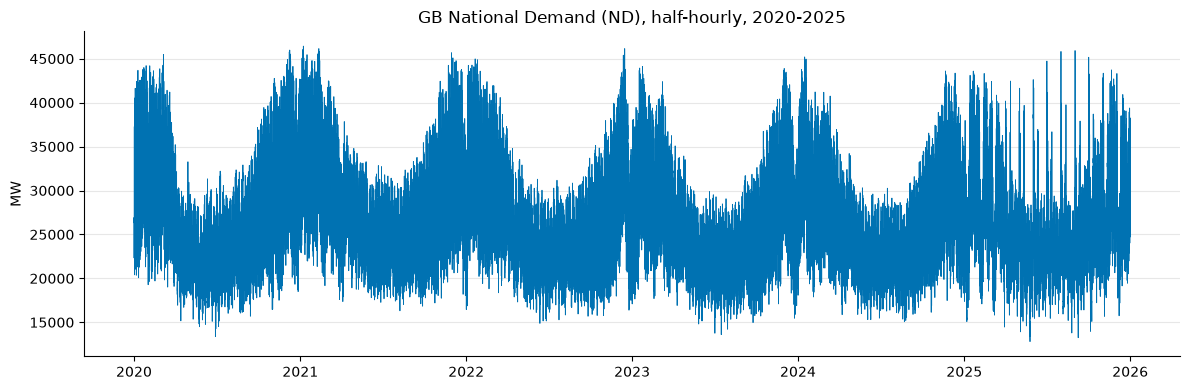

In [9]:
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(core.index, core["demand"], color=PALETTE["demand"], linewidth=0.6)
ax.set_title("GB National Demand (ND), half-hourly, 2020-2025")
ax.set_ylabel("MW")
ax.spines[["top", "right"]].set_visible(False)
ax.grid(axis="y", alpha=0.3)
fig.tight_layout()

## Zoomed: one winter week vs. one summer week

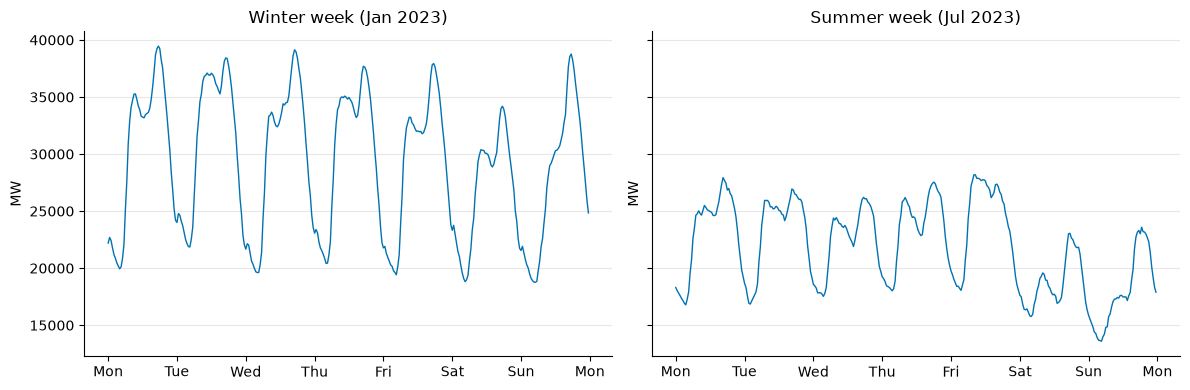

In [10]:
winter = core.loc["2023-01-09":"2023-01-15"]
summer = core.loc["2023-07-10":"2023-07-16"]

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
axes[0].plot(winter.index, winter["demand"], color=PALETTE["demand"], linewidth=1)
axes[0].set_title("Winter week (Jan 2023)")
axes[1].plot(summer.index, summer["demand"], color=PALETTE["demand"], linewidth=1)
axes[1].set_title("Summer week (Jul 2023)")
for ax in axes:
    ax.set_ylabel("MW")
    ax.spines[["top", "right"]].set_visible(False)
    ax.grid(axis="y", alpha=0.3)
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%a"))
fig.tight_layout()

## Seasonality: demand by hour of day and day of week

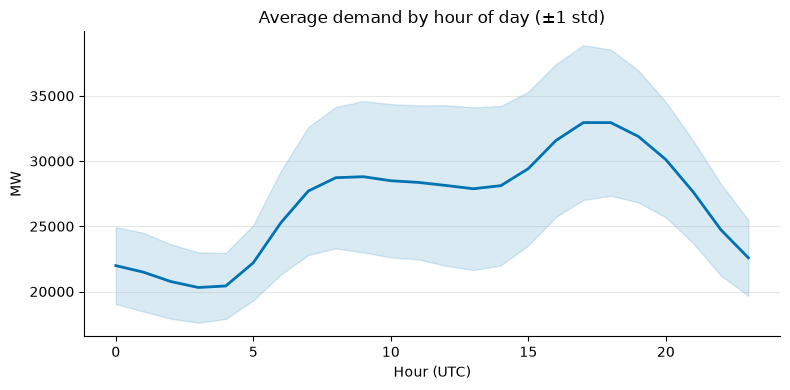

In [11]:
hourly = core["demand"].groupby(core.index.hour).agg(["mean", "std"])

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(hourly.index, hourly["mean"], color=PALETTE["demand"], linewidth=2)
ax.fill_between(
    hourly.index, hourly["mean"] - hourly["std"], hourly["mean"] + hourly["std"],
    color=PALETTE["demand"], alpha=0.15,
)
ax.set_title("Average demand by hour of day (±1 std)")
ax.set_xlabel("Hour (UTC)")
ax.set_ylabel("MW")
ax.spines[["top", "right"]].set_visible(False)
ax.grid(axis="y", alpha=0.3)
fig.tight_layout()

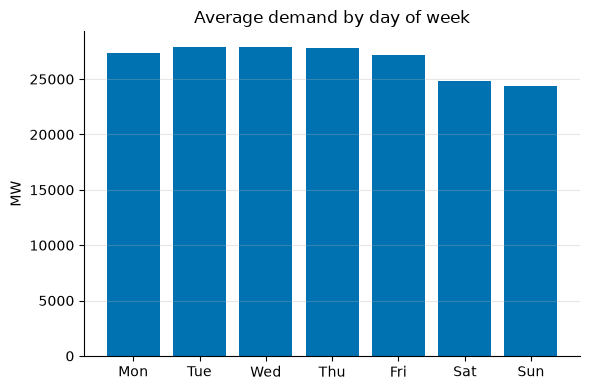

In [12]:
dow_labels = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]
dow = core["demand"].groupby(core.index.dayofweek).mean()

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(dow_labels, dow.values, color=PALETTE["demand"])
ax.set_title("Average demand by day of week")
ax.set_ylabel("MW")
ax.spines[["top", "right"]].set_visible(False)
ax.grid(axis="y", alpha=0.3)
fig.tight_layout()

## Year-over-year monthly average demand

Years are an *ordered* category, so a single-hue sequential ramp (light → dark = earlier → later) is used instead of unrelated categorical colors.

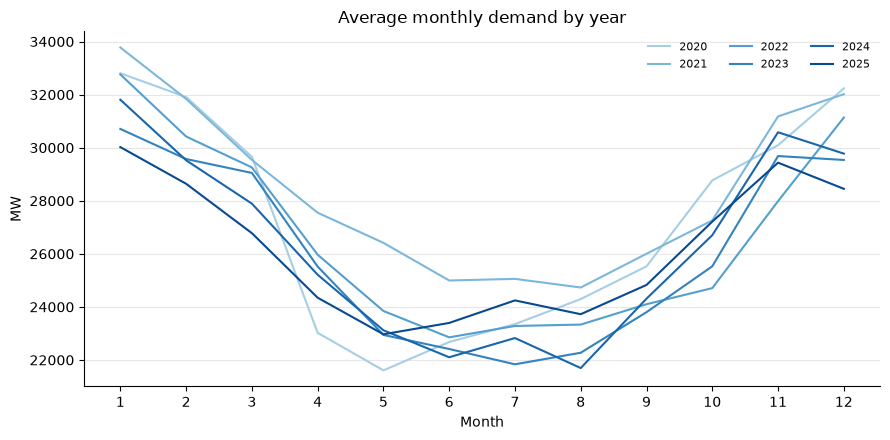

In [13]:
monthly = core["demand"].groupby([core.index.year, core.index.month]).mean().unstack(0)
years = sorted(monthly.columns)
colors = plt.cm.Blues([0.35 + 0.55 * i / (len(years) - 1) for i in range(len(years))])

fig, ax = plt.subplots(figsize=(9, 4.5))
for year, color in zip(years, colors):
    ax.plot(monthly.index, monthly[year], color=color, linewidth=1.5, label=str(year))
ax.set_title("Average monthly demand by year")
ax.set_xlabel("Month")
ax.set_ylabel("MW")
ax.set_xticks(range(1, 13))
ax.legend(ncol=3, fontsize=8, frameon=False)
ax.spines[["top", "right"]].set_visible(False)
ax.grid(axis="y", alpha=0.3)
fig.tight_layout()

## Wind and solar generation over time

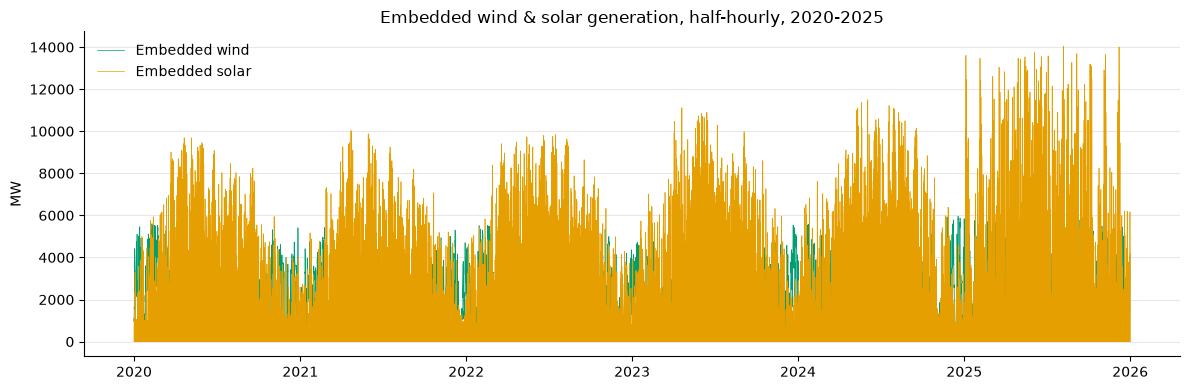

In [14]:
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(core.index, core["wind"], color=PALETTE["wind"], linewidth=0.5, label="Embedded wind")
ax.plot(core.index, core["solar"], color=PALETTE["solar"], linewidth=0.5, label="Embedded solar")
ax.set_title("Embedded wind & solar generation, half-hourly, 2020-2025")
ax.set_ylabel("MW")
ax.legend(frameon=False)
ax.spines[["top", "right"]].set_visible(False)
ax.grid(axis="y", alpha=0.3)
fig.tight_layout()

## Interconnector flow

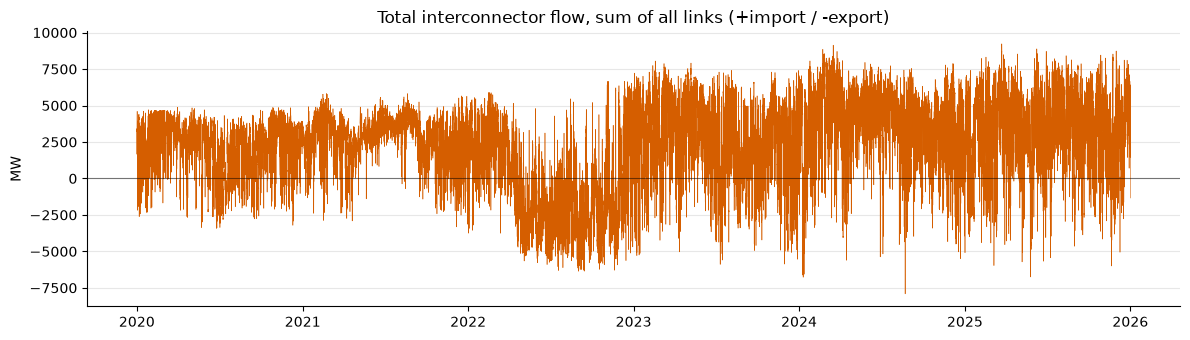

In [15]:
fig, ax = plt.subplots(figsize=(12, 3.5))
ax.plot(core.index, core["interconnector"], color=PALETTE["interconnector"], linewidth=0.4)
ax.axhline(0, color="black", linewidth=0.8, alpha=0.5)
ax.set_title("Total interconnector flow, sum of all links (+import / -export)")
ax.set_ylabel("MW")
ax.spines[["top", "right"]].set_visible(False)
ax.grid(axis="y", alpha=0.3)
fig.tight_layout()

## Combined embedded renewable output (wind + solar)

Since embedded wind/solar are features rather than something to net out of demand (see above), the quantity worth eyeballing is `wind + solar` itself — Week 7 will bucket forecast error by this, checking whether accuracy/calibration degrades when embedded-renewable output (and therefore unobserved weather-driven variance inside `demand`) is high.

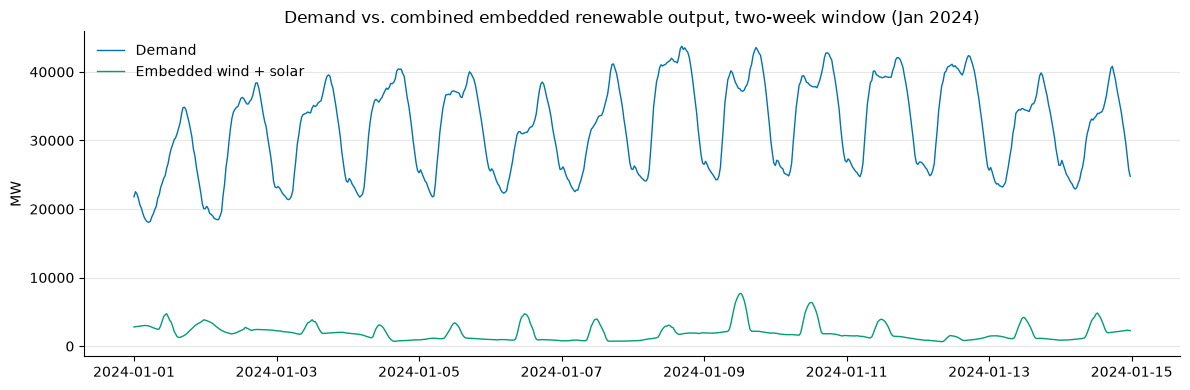

In [16]:
window = core.loc["2024-01-01":"2024-01-14"]
combined_renewables = window["wind"] + window["solar"]

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(window.index, window["demand"], color=PALETTE["demand"], linewidth=1, label="Demand")
ax.plot(
    window.index, combined_renewables, color=PALETTE["wind"], linewidth=1,
    label="Embedded wind + solar",
)
ax.set_title("Demand vs. combined embedded renewable output, two-week window (Jan 2024)")
ax.set_ylabel("MW")
ax.legend(frameon=False)
ax.spines[["top", "right"]].set_visible(False)
ax.grid(axis="y", alpha=0.3)
fig.tight_layout()

## Is ND's decline real, or a growing-renewables artifact?

Since embedded wind/solar generation is already invisibly netted out of `ND` (see `PLAN.md`), adding it back gives a proxy for the *true* underlying demand ND is hiding: `true_demand_proxy = ND + EMBEDDED_WIND_GENERATION + EMBEDDED_SOLAR_GENERATION`. If ND's downward trend since 2020 is mostly more rooftop solar/wind quietly appearing, `true_demand_proxy` should decline much less than `ND` itself, while installed embedded capacity visibly grows.

In [17]:
true_demand_proxy = df["ND"] + df["EMBEDDED_WIND_GENERATION"] + df["EMBEDDED_SOLAR_GENERATION"]
embedded_capacity = df["EMBEDDED_WIND_CAPACITY"] + df["EMBEDDED_SOLAR_CAPACITY"]

annual_nd = df["ND"].groupby(df.index.year).mean()
annual_true = true_demand_proxy.groupby(df.index.year).mean()
annual_capacity = embedded_capacity.groupby(df.index.year).mean()

nd_change = (annual_nd[2025] / annual_nd[2020] - 1) * 100
true_change = (annual_true[2025] / annual_true[2020] - 1) * 100
capacity_change = (annual_capacity[2025] / annual_capacity[2020] - 1) * 100
print(f"ND change, 2020->2025: {nd_change:+.1f}%")
print(f"True-demand-proxy change, 2020->2025: {true_change:+.1f}%")
print(f"Embedded wind+solar capacity change, 2020->2025: {capacity_change:+.1f}%")

ND change, 2020->2025: -3.7%
True-demand-proxy change, 2020->2025: -1.2%
Embedded wind+solar capacity change, 2020->2025: +39.2%


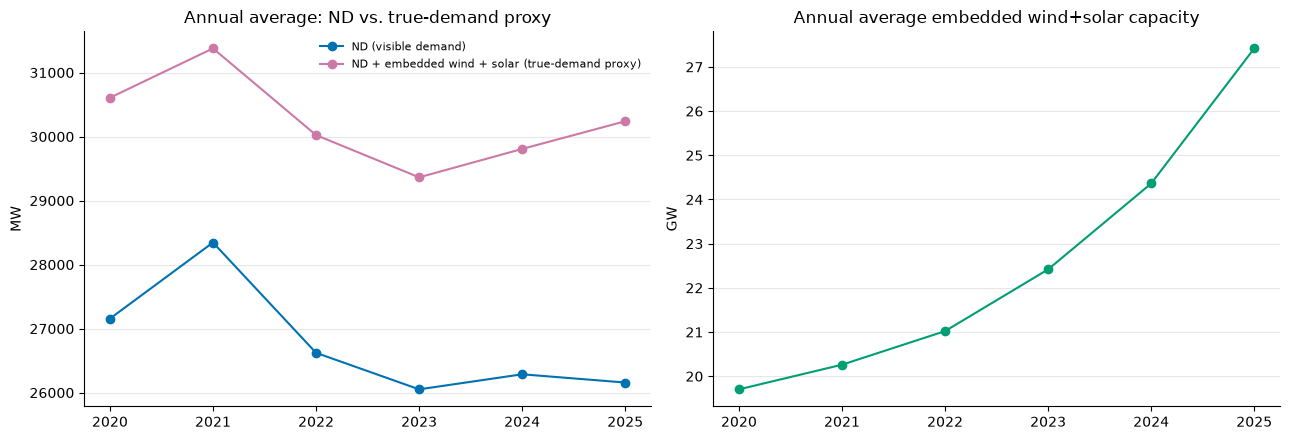

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].plot(annual_nd.index, annual_nd.values, color=PALETTE["demand"], marker="o", label="ND (visible demand)")
axes[0].plot(annual_true.index, annual_true.values, color="#CC79A7",
             marker="o", label="ND + embedded wind + solar (true-demand proxy)")
axes[0].set_title("Annual average: ND vs. true-demand proxy")
axes[0].set_ylabel("MW")
axes[0].legend(frameon=False, fontsize=8)

axes[1].plot(annual_capacity.index, annual_capacity.values / 1000, color=PALETTE["wind"], marker="o")
axes[1].set_title("Annual average embedded wind+solar capacity")
axes[1].set_ylabel("GW")

for ax in axes:
    ax.spines[["top", "right"]].set_visible(False)
    ax.grid(axis="y", alpha=0.3)
fig.tight_layout()

**Reading the result honestly, not as a clean story either way:** ND fell ~3.7% over 2020-2025 while embedded wind+solar capacity grew ~39% — but the true-demand proxy fell by only about a third as much as ND did (~1.2%). So **roughly two-thirds of the apparent ND decline is a growing-renewables visibility artifact, not real demand reduction** — but not all of it: there's still a genuine ~1.2% underlying decline unaccounted for by this factor alone (candidates: efficiency improvements, mild-winter years, deindustrialisation — not controlled for here, since none of this is weather-normalized; a cold year and a mild year will move both series regardless of capacity). 2021 stands out as the highest-demand year in both series — plausibly a colder winter, not just a COVID-rebound effect, since 2021 still had lockdown 3 running through Q1. Worth revisiting with heating-degree-day normalization in Week 4.

## Interconnector flow: direction, correlation, and new links appearing in real time

GB added interconnector capacity during this exact window — North Sea Link (Norway) went live 1 Oct 2021, Viking Link (Denmark) 29 Dec 2023, and Greenlink (Ireland) 30 Jan 2025. The raw per-link flow columns should show this directly: near-zero before go-live, real flows after.

In [19]:
for col, go_live in [("NSL_FLOW", "2021-10-01"), ("VIKING_FLOW", "2023-12-29"), ("GREENLINK_FLOW", "2025-01-30")]:
    before = df.loc[:go_live, col].iloc[:-1].abs().mean()
    after = df.loc[go_live:, col].abs().mean()
    print(f"{col}: mean |flow| before go-live = {before:.1f} MW, after = {after:.1f} MW")

NSL_FLOW: mean |flow| before go-live = 6.4 MW, after = 997.2 MW
VIKING_FLOW: mean |flow| before go-live = 1.3 MW, after = 763.2 MW
GREENLINK_FLOW: mean |flow| before go-live = 3.2 MW, after = 402.8 MW


Correlation, interconnector vs wind generation: -0.15831571506210718
Correlation, interconnector vs demand: 0.21251585059363157


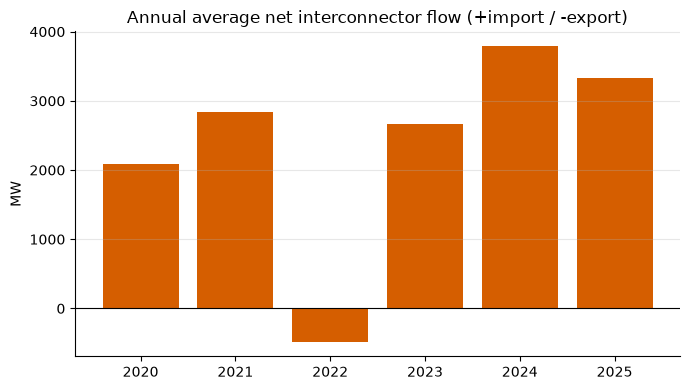

In [20]:
annual_interconnector = core["interconnector"].groupby(core.index.year).mean()

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(annual_interconnector.index.astype(str), annual_interconnector.values, color=PALETTE["interconnector"])
ax.axhline(0, color="black", linewidth=0.8)
ax.set_title("Annual average net interconnector flow (+import / -export)")
ax.set_ylabel("MW")
ax.spines[["top", "right"]].set_visible(False)
ax.grid(axis="y", alpha=0.3)
fig.tight_layout()

print("Correlation, interconnector vs wind generation:", core["interconnector"].corr(core["wind"]))
print("Correlation, interconnector vs demand:", core["interconnector"].corr(core["demand"]))

**Findings:** GB is a net importer in every year except **2022** (net exporter, on average) — plausibly tied to the 2022 European gas price crisis following Russia's invasion of Ukraine (Feb 2022), which may have made continental gas-fired generation relatively more expensive than GB's own mix that year; worth checking against actual price data later rather than asserting it from this alone. The correlations are weak but directionally sensible: slightly *negative* with wind generation (some tendency to export more/import less when wind is high) and slightly *positive* with demand (some tendency to import more when demand is high) — consistent with interconnectors acting as a release valve in both directions, just not a dominant one.

## Notes / next steps

- Record here anything that looks wrong (spikes, flat-lined sensors, sign errors) so the Week 1 cleaning step has a concrete list to act on, rather than guessing at rules.
- Decide the canonical demand/wind/solar/interconnector columns and units to freeze for the rest of the project.
- Confirm the train/validation/test date ranges from `PLAN.md` before Week 2 baselines.